In [16]:
import sys
import json
from shapely.geometry import LineString

# poly = [
# 	[-73.76343785810529, 45.42492256321245],
# 	[-73.69924976027211, 45.55480344886365],
# 	[-73.50960310758373, 45.53181488567199],
# 	[-73.46729731583024, 45.44232555570369],
# 	[-73.50303841575999, 45.41673106272731],
# 	[-73.76343785810529, 45.42492256321245],
# ]
# highway = [
# 	'motorway',
# 	'motorway_link',
# 	'trunk',
# 	'trunk_link',
# 	'primary',
# 	'primary_link',
# 	'secondary',
# 	'secondary_link',
# 	'tertiary',
# 	'tertiary_link',
# 	'residential',
# ]

poly = [
	[-73.68843594532505, 45.44440233371736],
	[-73.68839910204119, 45.552179931161376],
	[-73.4522748979573, 45.552179931161376],
	[-73.45223805467343, 45.44440233371736],
	[-73.68843594532505, 45.44440233371736],
]
highway = ['motorway', 'motorway_link', 'trunk', 'trunk_link', 'primary', 'primary_link']
highway = ['motorway', 'motorway_link', 'trunk', 'trunk_link', 'primary', 'primary_link', 'cycleway']

params = {'poly': poly, 'highway': highway, 'elevation': True, 'extended_cycleway': True}


default = {'scenario': 'test', 'training_folder': '../..', 'params': params}  # Default execution parameters
manual, argv = (True, default) if 'ipykernel' in sys.argv[0] else (False, dict(default, **json.loads(sys.argv[1])))

In [17]:
from osm_importer import overpass
from osm_importer.importer import import_road_network, simplify_bicycle_network, simplify_road_network


In [18]:
params = argv['params']
add_elevation = params['elevation']
extended_cycleway = params['extended_cycleway']
split_direction = False


In [19]:
# get bbox or a polygon
poly = params['poly']
bbox = overpass.get_bbox(poly)
# get requested highway
highway_list = params['highway']

In [20]:
CYCLEWAY_COLUMNS = ['cycleway:both', 'cycleway:left', 'cycleway:right']
HIGHWAY_COLUMNS = ['highway', 'maxspeed', 'lanes', 'name', 'oneway', 'surface']


In [21]:
highway_list

['motorway',
 'motorway_link',
 'trunk',
 'trunk_link',
 'primary',
 'primary_link',
 'cycleway']

In [22]:
cycleway_list = None
if 'cycleway' in highway_list:
	cycleway_list = [
		'lane',
		'opposite',
		'opposite_lane',
		'track',
		'opposite_track',
		'share_busway',
		'opposite_share_busway',
		'shared_lane',
	]
	if extended_cycleway:
		cycleway_list = []  # all

columns = HIGHWAY_COLUMNS.copy()
# if cycleway is requested. add cyclway tags to the request.
# https://wiki.openstreetmap.org/wiki/Map_features#When_cycleway_is_drawn_as_its_own_way_(see_Bicycle)
if cycleway_list is not None:
	if extended_cycleway:
		columns += ['cycleway']
	else:
		columns += CYCLEWAY_COLUMNS
		columns += ['cycleway']


In [23]:
print(columns)
print(cycleway_list)

['highway', 'maxspeed', 'lanes', 'name', 'oneway', 'surface', 'cycleway']
[]


In [24]:
links, nodes = import_road_network(bbox, highway_list, cycleway_list, columns)
links.index = [f'rlink_{i}' for i in links.index]
links['a'] = links['a'].apply(lambda x: f'rnode_{x}')
links['b'] = links['b'].apply(lambda x: f'rnode_{x}')
nodes.index = [f'rnode_{i}' for i in nodes.index]

In [25]:
import geopandas as gpd
from shapely.geometry import Polygon

print('restrict links to polygon')
poly_df = gpd.GeoDataFrame(geometry=[Polygon(poly)], crs=4326)
links = gpd.sjoin(links, poly_df, how='inner', predicate='intersects').drop(columns='index_right')

restrict links to polygon


In [26]:
if 'cycleway' in links.columns:
	links = simplify_bicycle_network(links, highway_list, extended_cycleway)
else:
	print('no cycleways')

In [27]:
links, nodes = simplify_road_network(links, nodes, add_elevation, split_direction)

<Axes: >

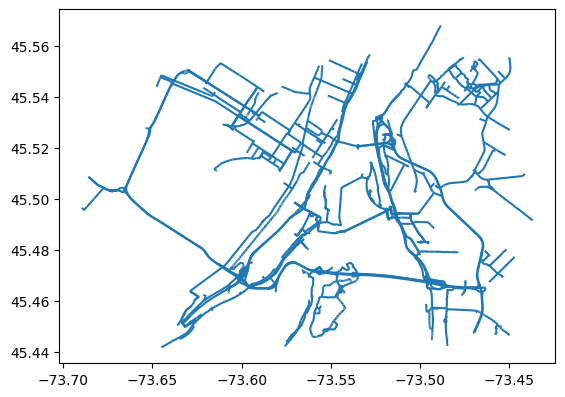

In [28]:
links.plot()

In [29]:
links

,highway,speed,lanes,name,oneway,surface,cycleway,geometry,a,b,cycleway_reverse,length,time,incline
rlink_0,motorway,70.0,2.0,Autoroute des Laurentides,False,concrete,No,"LINESTRING (-73.65203 45.5274, -73.65262 45.52...",rnode_2946,rnode_2647,No,106.303678,5.467046,-2.692926
rlink_1,motorway,70.0,2.0,Autoroute des Laurentides,False,asphalt,No,"LINESTRING (-73.65327 45.52776, -73.65378 45.5...",rnode_2647,rnode_6099,No,40.326207,2.073919,0.000000
rlink_2,secondary,40.0,2.0,Boulevard Rosemont,False,asphalt,No,"LINESTRING (-73.59429 45.53566, -73.59377 45.5...",rnode_8546,rnode_7055,No,76.969165,6.927225,-0.744357
rlink_3,cycleway,10.0,NaN,Écluse de St-Lambert,False,asphalt,Shared bike path,"LINESTRING (-73.51763 45.49167, -73.51744 45.4...",rnode_4028,rnode_640,Shared bike path,60.486367,21.775092,1.893812
rlink_4,primary_link,50.0,1.0,NaN,True,asphalt,No,"LINESTRING (-73.51324 45.49405, -73.51258 45.4...",rnode_8280,rnode_8549,No,51.562849,3.712525,1.111044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rlink_2791,tertiary,30.0,3.0,Rue de la Commune Ouest,False,asphalt,No,"LINESTRING (-73.55299 45.49669, -73.55294 45.4...",rnode_3964,rnode_3471,No,83.515161,10.021819,0.000000
rlink_2792,tertiary,30.0,2.0,Rue Sainte-Catherine Est,False,asphalt,No,"LINESTRING (-73.53881 45.54301, -73.53784 45.5...",rnode_6280,rnode_6523,No,276.333134,33.159976,-0.207342
rlink_2793,tertiary,30.0,2.0,Avenue Laurier Ouest,False,asphalt,Painted bike lane,"LINESTRING (-73.59328 45.52255, -73.59332 45.5...",rnode_6395,rnode_3397,Painted bike lane,93.207240,11.184869,0.000000
rlink_2794,tertiary,30.0,2.0,Rue Sainte-Catherine Est,False,asphalt,No,"LINESTRING (-73.53741 45.54529, -73.53692 45.5...",rnode_6523,rnode_6378,No,384.948809,46.193857,-0.297677
